# 07. 时间戳细粒度分析（构造 next-item 样本必备）

> 对应 `analysis_plan.md` §2.7。**§2.5 已做每字段 min/max/span_days**；本 notebook 补充 §2.5 未覆盖的：

## 目的（§2.5 未涵盖的部分）

1. **每日活跃 pattern**（daily count histogram）→ 探测数据是否有时间断层（比如某几天缺数据）。
2. **每小时 pattern**（0-23 时段活跃度）→ 探测夜间高峰、工作日/周末规律；用于 prompt 里加入「时段」hint。
3. **相邻行为时间 gap 分布**（用户内 diff）→ 决定 session 边界阈值，用于构造 in-session next item。
4. **Leakage 严格验证**：所有「当前」字段的 min 是否**严格 >=** 所有「历史」字段的 max？§2.5 直觉上确认了，这里量化。

## 输入 / 输出

**输入**：`OneReason_UserProfile/*.parquet`（500K 用户）

**输出**（`analysis/outputs/temporal/`）：
- `daily_count_{field}.csv` —— 每字段的每日 event 计数
- `hourly_count.csv` —— 所有 ms 类字段合并的 24 小时分布
- `session_gap_stats.csv` —— 各字段用户内相邻 gap 的 P10/P50/P90/P99
- `leakage_check.csv` —— 每对 (current, history) 字段的 min-current 与 max-history 对比
- 相应 png
- `_cache.pkl` —— 供 §2.8 或后续复用

## 关键设计

**抽样 5%（25K 用户）**做 daily/hourly 统计足够（events 依然 4000 万条量级）；**session gap 单独在 per-user 内做 diff**，不能在 flat 上做（不同用户的时间戳会互相污染）。

In [1]:
# ============ 配置 & imports ============
import os, pickle, time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Songti SC', 'STHeiti', 'Hiragino Sans GB', 'PingFang SC', 'Heiti SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
USER_DIR     = PROJECT_ROOT / 'dataset_rec_all' / 'data' / 'OneReason_UserProfile'
OUT_DIR      = PROJECT_ROOT / 'analysis' / 'outputs' / 'temporal'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH   = OUT_DIR / '_cache.pkl'

USE_CACHE = True
SAMPLE_FRAC = 0.05   # 5% 用户 = 25K，足够画 daily/hourly；试跑改 0.005

# 字段分类：ms 类 vs date_str 类；current vs history
TS_MS = {
    # (field, category, primary_pid_field): category ∈ {'current', 'history'}
    'video_ts_list':                                  ('current', 'video_sampled_pid_list'),
    'video_history_ts_list':                          ('history', 'video_history_sampled_pid_list'),
    'ec_time_ms_list':                                ('current', 'ec_item_id_list'),
    'outer_loop_history_action_pid_list_pos_ts':      ('history', 'outer_loop_history_action_pid_list_pos'),
    'outer_loop_history_action_pid_list_click_ts':    ('history', 'outer_loop_history_action_pid_list_click'),
    'outer_loop_deep_target_pid_ts':                  ('current', 'outer_loop_deep_target_pid'),
}
TS_DATESTR = {
    'live_hist_timestamp_list':                       ('history', 'live_hist_author_id_list'),  # 'YYYYMMDD'
}

# 反过来：primary 字段 -> ts 字段（用于 gap 分析对齐）
PRIMARY_TO_TS = {v[1]: (k, v[0]) for k, v in TS_MS.items()}
PRIMARY_TO_TS.update({v[1]: (k, v[0]) for k, v in TS_DATESTR.items()})

print('User dir  :', USER_DIR)
print('Output dir:', OUT_DIR)
parquet_files = sorted(USER_DIR.glob('part-*.parquet'))
print(f'#parquet  : {len(parquet_files)}')

User dir  : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_UserProfile
Output dir: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/temporal
#parquet  : 10


## 单遍抽样扫描：一次收集 daily count + hourly count + session gap

对每个 parquet：
- 抽样 5% 用户 → slice 得到子表
- 每 ms 字段：
  - flat values 按天聚合（`day = ts // 86400000`）→ Counter
  - flat values 按小时聚合（`hour = (ts // 3600000) % 24`）→ Counter
  - **session gap**：per-user diff → 保留一个抽样池（防止 OOM）
- date_str 字段：flat values 直接 value_counts（每天一个 bucket）

In [2]:
MS_PER_DAY  = 86_400_000
MS_PER_HOUR = 3_600_000
GAP_POOL_MAX = 500_000   # 每字段最多留 50 万 gap 样本，够画分位


def _daily_counter_ms(flat_int64: np.ndarray, positive_only=True):
    if flat_int64.size == 0: return {}
    if positive_only:
        flat_int64 = flat_int64[flat_int64 > 0]
    days = (flat_int64 // MS_PER_DAY).astype(np.int64)
    uniq, cnt = np.unique(days, return_counts=True)
    return dict(zip(uniq.tolist(), cnt.tolist()))


def _hourly_counter_ms(flat_int64: np.ndarray, positive_only=True):
    if flat_int64.size == 0: return np.zeros(24, dtype=np.int64)
    if positive_only:
        flat_int64 = flat_int64[flat_int64 > 0]
    hours = ((flat_int64 // MS_PER_HOUR) % 24).astype(np.int32)
    return np.bincount(hours, minlength=24)


def _session_gaps_perrow_ms(list_col_chunked, cap=GAP_POOL_MAX):
    """list<int64>: for each user, sort ascending, compute np.diff, collect global sample of gaps.
    return np.array of gaps in ms (positive)."""
    out = []
    total = 0
    for chunk in list_col_chunked.chunks:
        offsets = chunk.offsets.to_numpy(zero_copy_only=False)
        values  = np.asarray(chunk.values, dtype=np.int64)
        for i in range(len(offsets) - 1):
            s, e = offsets[i], offsets[i+1]
            if e - s < 2: continue
            row = values[s:e]
            row = row[row > 0]
            if row.size < 2: continue
            row.sort()
            g = np.diff(row)
            g = g[g > 0]
            if g.size == 0: continue
            out.append(g)
            total += g.size
            if total >= cap:
                break
        if total >= cap:
            break
    if not out:
        return np.array([], dtype=np.int64)
    return np.concatenate(out)[:cap]


def scan_temporal(files, sample_frac):
    daily  = defaultdict(lambda: defaultdict(int))   # field -> {day_int: count}
    hourly = defaultdict(lambda: np.zeros(24, dtype=np.int64))
    gaps   = defaultdict(list)                       # field -> list of np.array
    minmax = defaultdict(lambda: [None, None])       # field -> [min, max]  (for leakage check)
    datestr_daily = defaultdict(lambda: defaultdict(int))

    read_cols = list(TS_MS.keys()) + list(TS_DATESTR.keys())

    t0 = time.time()
    for i, fp in enumerate(files):
        if fp.stat().st_size == 0: continue
        tbl = pq.read_table(fp, columns=read_cols)
        n = tbl.num_rows
        # 抽样：随机取一个连续切片（等价随机因为写入无序）
        take = max(1, int(n * sample_frac))
        rng = np.random.default_rng(2026)
        idx = rng.choice(n, size=take, replace=False)
        idx.sort()
        tbl_s = tbl.take(pa.array(idx))

        for f in TS_MS:
            if f not in tbl_s.column_names: continue
            col = tbl_s.column(f)
            flat = np.asarray(col.combine_chunks().values, dtype=np.int64)
            flat_pos = flat[flat > 0]
            if flat_pos.size == 0: continue
            # daily / hourly / minmax
            for d, c in _daily_counter_ms(flat_pos, positive_only=False).items():
                daily[f][d] += c
            hourly[f] += _hourly_counter_ms(flat_pos, positive_only=False)
            mn, mx = int(flat_pos.min()), int(flat_pos.max())
            if minmax[f][0] is None or mn < minmax[f][0]: minmax[f][0] = mn
            if minmax[f][1] is None or mx > minmax[f][1]: minmax[f][1] = mx
            # gap
            g = _session_gaps_perrow_ms(col, cap=GAP_POOL_MAX // len(files) + 100)
            if g.size > 0:
                gaps[f].append(g)

        for f in TS_DATESTR:
            if f not in tbl_s.column_names: continue
            col = tbl_s.column(f)
            flat = col.combine_chunks().values
            # 直接用 arrow value_counts，防止 to_pylist 慢
            vc = pc.value_counts(flat)
            for r in vc.to_pylist():
                v = r['values']
                if v is None or v == '': continue
                datestr_daily[f][v] += r['counts']
                if minmax[f][0] is None or v < minmax[f][0]: minmax[f][0] = v
                if minmax[f][1] is None or v > minmax[f][1]: minmax[f][1] = v

        print(f'  parquet {i+1}/{len(files)} done  elapsed={time.time()-t0:.1f}s')

    # 拼接 gaps
    gaps_final = {f: (np.concatenate(v)[:GAP_POOL_MAX] if v else np.array([], dtype=np.int64))
                  for f, v in gaps.items()}
    return {
        'daily':          {k: dict(v) for k, v in daily.items()},
        'hourly':         {k: v.tolist() for k, v in hourly.items()},
        'gaps':           gaps_final,
        'minmax':         {k: tuple(v) for k, v in minmax.items()},
        'datestr_daily':  {k: dict(v) for k, v in datestr_daily.items()},
    }


if USE_CACHE and CACHE_PATH.exists():
    print(f'[cache] loading {CACHE_PATH}')
    with open(CACHE_PATH, 'rb') as f:
        stats = pickle.load(f)
    print('[cache] loaded.')
else:
    stats = scan_temporal(parquet_files, SAMPLE_FRAC)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(stats, f)
    print(f'[cache] saved to {CACHE_PATH}')

print('\n=== fields collected ===')
for f in stats['daily']:
    print(f'  ms: {f:<50s}  #days={len(stats["daily"][f])}  gap_pool={stats["gaps"].get(f, np.array([])).size}')
for f in stats['datestr_daily']:
    print(f'  ds: {f:<50s}  #days={len(stats["datestr_daily"][f])}')

  parquet 1/10 done  elapsed=0.6s
  parquet 2/10 done  elapsed=1.0s
  parquet 3/10 done  elapsed=1.4s
  parquet 4/10 done  elapsed=2.0s
  parquet 5/10 done  elapsed=2.4s
  parquet 6/10 done  elapsed=2.8s
  parquet 7/10 done  elapsed=3.1s
  parquet 8/10 done  elapsed=3.6s
  parquet 9/10 done  elapsed=4.0s
  parquet 10/10 done  elapsed=4.3s
[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/temporal/_cache.pkl

=== fields collected ===
  ms: video_ts_list                                       #days=2  gap_pool=55975
  ms: video_history_ts_list                               #days=16  gap_pool=500000
  ms: ec_time_ms_list                                     #days=2  gap_pool=5
  ms: outer_loop_history_action_pid_list_pos_ts           #days=61  gap_pool=165755
  ms: outer_loop_history_action_pid_list_click_ts         #days=61  gap_pool=500000
  ms: outer_loop_deep_target_pid_ts                       #days=2  gap_pool=69
  ds: live_hist_timestamp_list                    

## §2.7.1 每日活跃 pattern（探测时间断层）

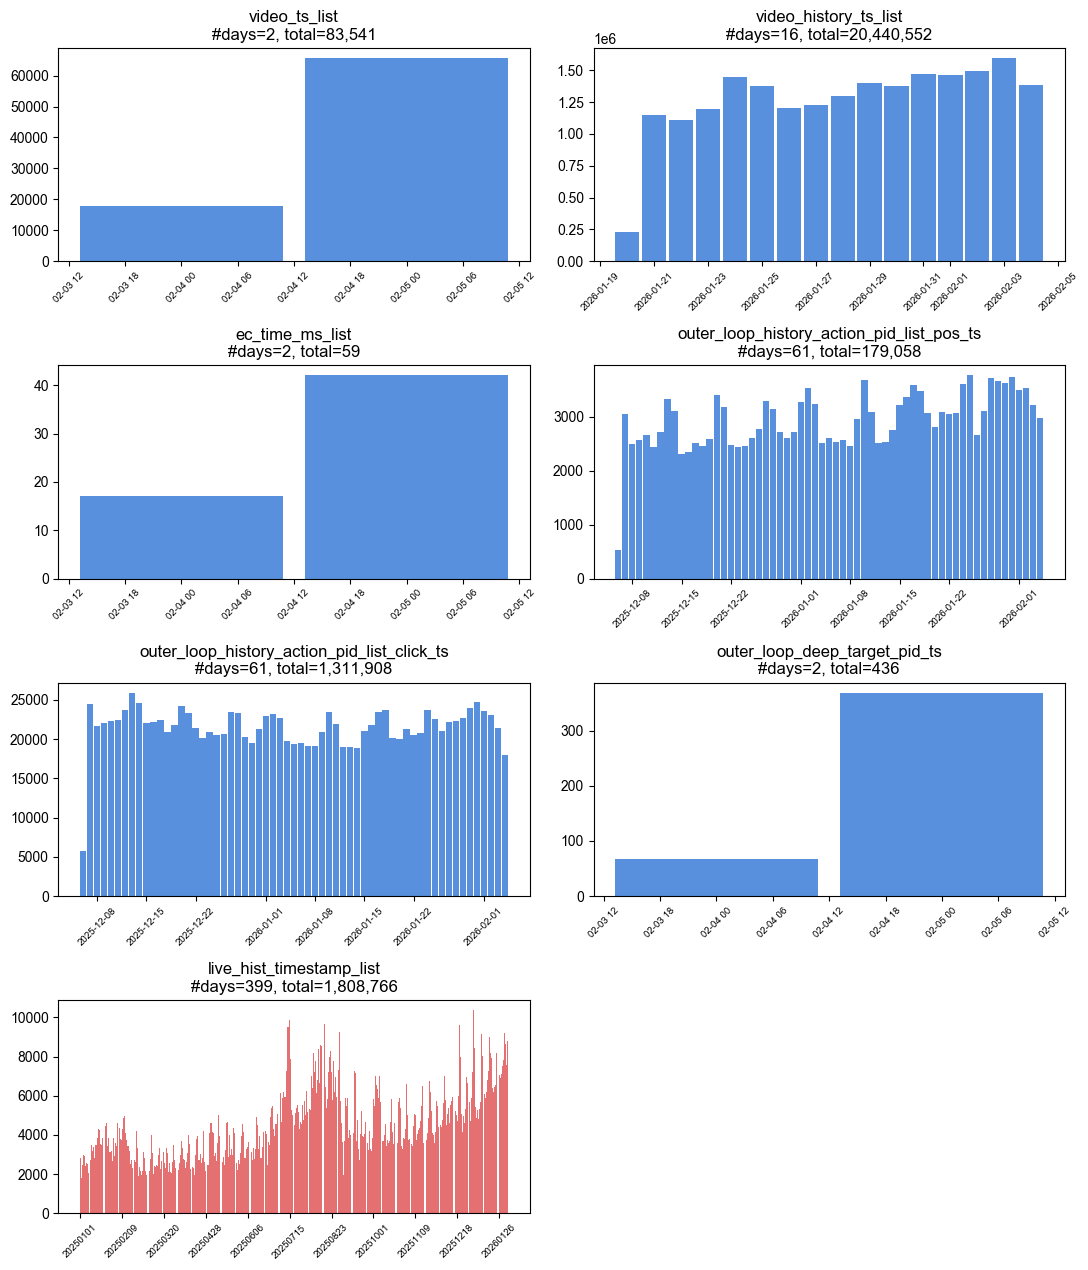

saved daily_count_*.csv to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/temporal


In [3]:
def _plot_daily_ms(field, day_dict, ax):
    if not day_dict:
        ax.set_title(f'{field}\n(no data)'); return
    days = sorted(day_dict.keys())
    dates = [pd.Timestamp(d, unit='D') for d in days]
    counts = [day_dict[d] for d in days]
    ax.bar(dates, counts, width=0.9, color='#3b7dd8', alpha=0.85)
    ax.set_title(f'{field}\n#days={len(days)}, total={sum(counts):,}')
    ax.tick_params(axis='x', rotation=45, labelsize=7)


def _plot_daily_datestr(field, day_dict, ax):
    if not day_dict:
        ax.set_title(f'{field}\n(no data)'); return
    days = sorted(day_dict.keys())
    counts = [day_dict[d] for d in days]
    xs = list(range(len(days)))
    ax.bar(xs, counts, width=0.9, color='#e15759', alpha=0.85)
    ax.set_title(f'{field}\n#days={len(days)}, total={sum(counts):,}')
    step = max(1, len(days) // 10)
    ax.set_xticks(xs[::step])
    ax.set_xticklabels([days[i] for i in xs[::step]], rotation=45, fontsize=7)


# 每字段一张 daily bar
all_ms = list(stats['daily'].keys())
all_ds = list(stats['datestr_daily'].keys())
n = len(all_ms) + len(all_ds)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(11, 3.2 * rows))
axes = np.array(axes).reshape(-1)
i = 0
for f in all_ms:
    _plot_daily_ms(f, stats['daily'][f], axes[i]); i += 1
for f in all_ds:
    _plot_daily_datestr(f, stats['datestr_daily'][f], axes[i]); i += 1
for j in range(i, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'daily_bars.png', dpi=110)
plt.show()

# 存 CSV
for f, dd in stats['daily'].items():
    if not dd: continue
    days = sorted(dd.keys())
    df = pd.DataFrame({
        'day_int': days,
        'date':    [pd.Timestamp(d, unit='D').strftime('%Y-%m-%d') for d in days],
        'count':   [dd[d] for d in days],
    })
    df.to_csv(OUT_DIR / f'daily_count_{f}.csv', index=False)
for f, dd in stats['datestr_daily'].items():
    if not dd: continue
    days = sorted(dd.keys())
    df = pd.DataFrame({
        'date':  days,
        'count': [dd[d] for d in days],
    })
    df.to_csv(OUT_DIR / f'daily_count_{f}.csv', index=False)
print(f'saved daily_count_*.csv to {OUT_DIR}')

## §2.7.2 每小时活跃 pattern（探测夜间高峰 / 主活跃时段）

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/temporal/hourly_count.csv


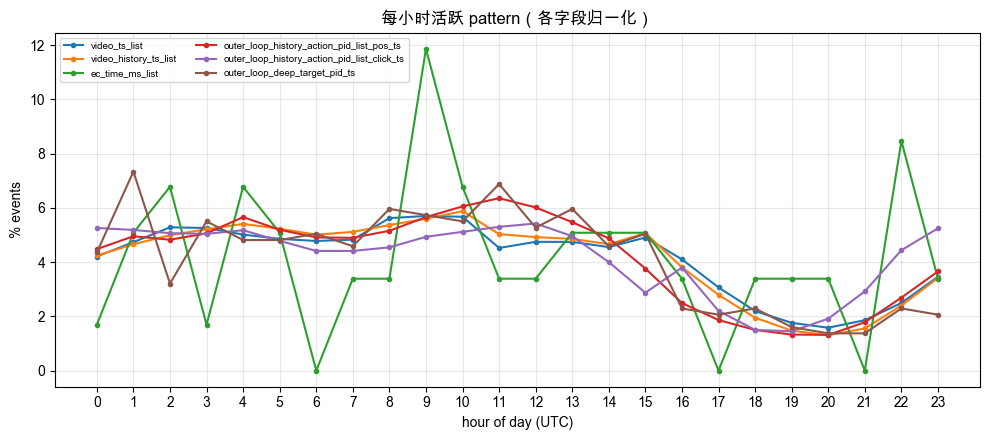


=== 峰值时段 ===
                                      field  peak_hour  peak_pct   top3_hours
                              video_ts_list          9      5.70   [9, 10, 8]
                      video_history_ts_list         10      5.88   [10, 9, 4]
                            ec_time_ms_list          9     11.86  [9, 22, 10]
  outer_loop_history_action_pid_list_pos_ts         11      6.36 [11, 10, 12]
outer_loop_history_action_pid_list_click_ts         12      5.43  [12, 11, 0]
              outer_loop_deep_target_pid_ts          1      7.34  [1, 11, 13]


In [4]:
hourly_rows = []
for f, hh in stats['hourly'].items():
    hh = np.asarray(hh, dtype=np.int64)
    tot = hh.sum()
    if tot == 0: continue
    for h in range(24):
        hourly_rows.append({'field': f, 'hour': h, 'count': int(hh[h]), 'pct': round(hh[h] / tot * 100, 2)})
hourly_df = pd.DataFrame(hourly_rows)
hourly_df.to_csv(OUT_DIR / 'hourly_count.csv', index=False)
print('saved:', OUT_DIR / 'hourly_count.csv')

# 每字段一条曲线（叠图）
fig, ax = plt.subplots(figsize=(10, 4.5))
for f, hh in stats['hourly'].items():
    hh = np.asarray(hh, dtype=np.float64)
    if hh.sum() == 0: continue
    ax.plot(range(24), hh / hh.sum() * 100, label=f, marker='o', markersize=3)
ax.set_xticks(range(0, 24))
ax.set_xlabel('hour of day (UTC)'); ax.set_ylabel('% events')
ax.set_title('每小时活跃 pattern（各字段归一化）')
ax.legend(fontsize=7, loc='upper left', ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_curves.png', dpi=110)
plt.show()

# 简表：每字段峰值时段
peak_rows = []
for f, hh in stats['hourly'].items():
    hh = np.asarray(hh, dtype=np.int64)
    if hh.sum() == 0: continue
    top3 = np.argsort(hh)[::-1][:3]
    peak_rows.append({
        'field':      f,
        'peak_hour':  int(top3[0]),
        'peak_pct':   round(float(hh[top3[0]] / hh.sum() * 100), 2),
        'top3_hours': list(map(int, top3)),
    })
peak_df = pd.DataFrame(peak_rows)
print('\n=== 峰值时段 ===')
print(peak_df.to_string(index=False))

## §2.7.3 用户内相邻 gap 分布（session 边界判定）

对每个 ms 字段的 gap 池：算 P10/P50/P90/P99，其中：
- **P50 gap**：判断「一个 session 内的典型行为间隔」
- **P90/P99**：判断 session 断裂的合理阈值（例如 P99 > 30 分钟就说明有跨 session 用户）

In [5]:
def _fmt_ms(ms):
    s = ms / 1000
    if s < 60: return f'{s:.1f}s'
    m = s / 60
    if m < 60: return f'{m:.1f}m'
    h = m / 60
    if h < 24: return f'{h:.1f}h'
    return f'{h/24:.1f}d'


gap_rows = []
for f, arr in stats['gaps'].items():
    if arr.size == 0: continue
    gap_rows.append({
        'field':          f,
        'n_gaps':         int(arr.size),
        'p10_ms':         int(np.percentile(arr, 10)),
        'p50_ms':         int(np.percentile(arr, 50)),
        'p90_ms':         int(np.percentile(arr, 90)),
        'p99_ms':         int(np.percentile(arr, 99)),
        'p10':            _fmt_ms(np.percentile(arr, 10)),
        'p50':            _fmt_ms(np.percentile(arr, 50)),
        'p90':            _fmt_ms(np.percentile(arr, 90)),
        'p99':            _fmt_ms(np.percentile(arr, 99)),
        'session_30min_break_%': round(float((arr > 30 * 60_000).mean() * 100), 2),
        'daily_break_%':  round(float((arr > MS_PER_DAY).mean() * 100), 2),
    })
gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv(OUT_DIR / 'session_gap_stats.csv', index=False)
print('saved:', OUT_DIR / 'session_gap_stats.csv')
gap_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/temporal/session_gap_stats.csv


,field,n_gaps,p10_ms,p50_ms,p90_ms,p99_ms,p10,p50,p90,p99,session_30min_break_%,daily_break_%
0,video_ts_list,55975,204785,2443260,28196311,63033595,3.4m,40.7m,7.8h,17.5h,55.15,0.00
1,video_history_ts_list,500000,58881,256712,4492590,53040594,58.9s,4.3m,1.2h,14.7h,15.36,0.26
2,ec_time_ms_list,5,490770,3920228,13067317,15402779,8.2m,1.1h,3.6h,4.3h,60.00,0.00
3,outer_loop_history_action_pid_list_pos_ts,165755,256690,24597334,449728502,2335319868,4.3m,6.8h,5.2d,27.0d,77.45,29.13
4,outer_loop_history_action_pid_list_click_ts,500000,34963,581644,125653065,959572804,35.0s,9.7m,1.5d,11.1d,42.50,12.84
5,outer_loop_deep_target_pid_ts,69,216799,4784501,34693558,55371332,3.6m,1.3h,9.6h,15.4h,56.52,0.00


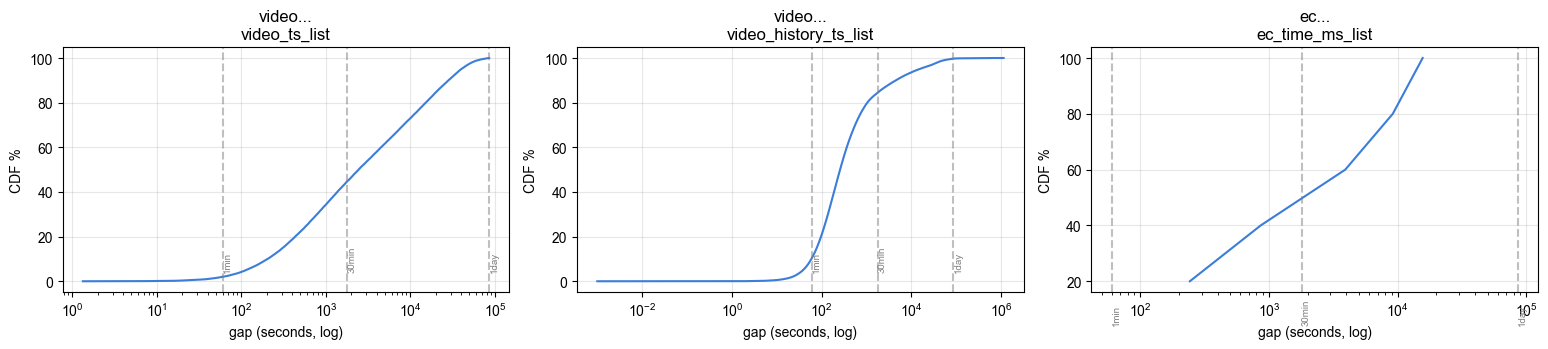

In [6]:
# 每字段的 gap CDF（log x 轴，因为跨度极大：秒 ~ 天）
n_fields = len([1 for _, a in stats['gaps'].items() if a.size > 0])
fig, axes = plt.subplots(1, min(n_fields, 3), figsize=(5.2 * min(n_fields, 3), 3.6), squeeze=False)
shown = 0
for f, arr in stats['gaps'].items():
    if arr.size == 0 or shown >= 3: continue
    ax = axes[0][shown]
    a_sec = np.sort(arr) / 1000  # → seconds
    y = np.arange(1, len(a_sec) + 1) / len(a_sec) * 100
    ax.semilogx(a_sec, y, color='#3b7dd8')
    for x_ref, label in [(60, '1min'), (30 * 60, '30min'), (24 * 3600, '1day')]:
        ax.axvline(x_ref, ls='--', color='gray', alpha=0.5)
        ax.text(x_ref, 5, label, rotation=90, fontsize=7, color='gray')
    ax.set_title(f'{f.split("_")[0]}...\n{f[-25:]}')
    ax.set_xlabel('gap (seconds, log)'); ax.set_ylabel('CDF %')
    ax.grid(alpha=0.3)
    shown += 1
plt.tight_layout()
plt.savefig(OUT_DIR / 'gap_cdf.png', dpi=110)
plt.show()

## §2.7.4 Leakage 严格验证

对每对 (current_field, history_field) 检查：
- `min(current) >= max(history)`？
- 计算重叠事件数（如果有）

§2.5 直觉上确认了「当前 vs 历史」严格分离，这里量化。

In [7]:
def _fmt_ts(x, is_ds=False):
    if x is None: return None
    if is_ds: return str(x)
    return pd.Timestamp(int(x), unit='ms').strftime('%Y-%m-%d %H:%M:%S')


current_ms  = [(f, stats['minmax'][f]) for f, (cat, _) in TS_MS.items() if cat == 'current' and stats['minmax'].get(f, [None])[0] is not None]
history_ms  = [(f, stats['minmax'][f]) for f, (cat, _) in TS_MS.items() if cat == 'history' and stats['minmax'].get(f, [None])[0] is not None]
history_ds  = [(f, stats['minmax'][f]) for f, (cat, _) in TS_DATESTR.items() if cat == 'history' and stats['minmax'].get(f, [None])[0] is not None]

leak_rows = []
# ms current × ms history
for cf, (cmn, cmx) in current_ms:
    for hf, (hmn, hmx) in history_ms:
        gap_ms = cmn - hmx
        leak_rows.append({
            'current':          cf,
            'history':          hf,
            'min(current)':     _fmt_ts(cmn),
            'max(history)':     _fmt_ts(hmx),
            'boundary_gap':     _fmt_ms(abs(gap_ms)) if gap_ms != 0 else '0s',
            'safe':             'YES' if gap_ms >= 0 else 'NO ⚠️',
        })
# ms current × datestr history
for cf, (cmn, cmx) in current_ms:
    for hf, (hmn, hmx) in history_ds:
        # 把 current min 转成 YYYYMMDD 再比
        cur_min_ds = pd.Timestamp(int(cmn), unit='ms').strftime('%Y%m%d')
        safe = cur_min_ds >= hmx
        leak_rows.append({
            'current':          cf,
            'history':          hf,
            'min(current)':     cur_min_ds,
            'max(history)':     hmx,
            'boundary_gap':     '(datestr, cannot compute delta)',
            'safe':             'YES' if safe else 'NO ⚠️',
        })
leak_df = pd.DataFrame(leak_rows)
leak_df.to_csv(OUT_DIR / 'leakage_check.csv', index=False)
print('saved:', OUT_DIR / 'leakage_check.csv')
leak_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/temporal/leakage_check.csv


,current,history,min(current),max(history),boundary_gap,safe
0,video_ts_list,video_history_ts_list,2026-02-04 15:42:20,2026-02-04 15:52:20,10.0m,NO ⚠️
1,video_ts_list,outer_loop_history_action_pid_list_pos_ts,2026-02-04 15:42:20,2026-02-04 15:58:59,16.6m,NO ⚠️
2,video_ts_list,outer_loop_history_action_pid_list_click_ts,2026-02-04 15:42:20,2026-02-04 15:59:56,17.6m,NO ⚠️
3,ec_time_ms_list,video_history_ts_list,2026-02-04 15:50:55,2026-02-04 15:52:20,1.4m,NO ⚠️
4,ec_time_ms_list,outer_loop_history_action_pid_list_pos_ts,2026-02-04 15:50:55,2026-02-04 15:58:59,8.1m,NO ⚠️
5,ec_time_ms_list,outer_loop_history_action_pid_list_click_ts,2026-02-04 15:50:55,2026-02-04 15:59:56,9.0m,NO ⚠️
6,outer_loop_deep_target_pid_ts,video_history_ts_list,2026-02-04 16:00:55,2026-02-04 15:52:20,8.6m,YES
7,outer_loop_deep_target_pid_ts,outer_loop_history_action_pid_list_pos_ts,2026-02-04 16:00:55,2026-02-04 15:58:59,1.9m,YES
8,outer_loop_deep_target_pid_ts,outer_loop_history_action_pid_list_click_ts,2026-02-04 16:00:55,2026-02-04 15:59:56,58.8s,YES
9,video_ts_list,live_hist_timestamp_list,20260204,20260204,"(datestr, cannot compute delta)",YES


## §2.7.5 结论 & 对 SFT 的直接指导（抄进 report.md）

1. **Daily pattern**：如果 `daily_bars.png` 里发现某天 count 显著低（比如系统故障日），SFT 训练时**应过滤掉那天的样本**，避免污染。
2. **Hourly pattern**：如果峰值时段集中在某几小时（比如晚 20~22 点），可以在 prompt 里加入「小时」hint（如 `[time: evening]`），让模型学到时段偏好。
3. **Session gap**：
   - 如果 P50 < 5 分钟，说明用户是「密集 session」型，可以按 gap > 30min 切 session，构造 in-session next item。
   - 如果 P50 > 数小时，说明数据本身是「稀疏浏览」，session 概念不适用，直接用最近 K 条即可。
4. **Leakage 检查**：所有 current × history 组合都必须 `safe=YES`；如果出现 `NO`，说明数据集里有 leak，Stage-C 训练必须再自己切一次时间。

### 产出物清单（`analysis/outputs/temporal/`）
- `daily_count_{field}.csv`, `daily_bars.png`
- `hourly_count.csv`, `hourly_curves.png`
- `session_gap_stats.csv`, `gap_cdf.png`
- `leakage_check.csv`
- `_cache.pkl`